# Category Intelligence — Retail Product Performance EDA
**Calibo AI Academy · Path 2 · KLU Batch · Phase 1 — Mini Use Case 01**
**Group 10:** Mohammed Saalif Udyawar · Jakkana Hasini · Mohammed Mutee Ruknuddin

| Team member | Role | Sections owned |
|---|---|---|
| **Mohammed Saalif Udyawar** | Data Analyst | CBIM Problem Canvas (with the team) · Step 6.1 — load and inspect · Step 6.2 — category trends · Step 6.3 — top and bottom products |
| **Jakkana Hasini** | Insights Lead | Step 6.5 — day-of-week and monthly patterns |
| **Mohammed Mutee Ruknuddin** | Business Synthesiser | Setup and chart style · Step 6.4 — discount effectiveness · Step 6.6 — Category Manager Briefing · notebook integration |

*Review rule: each section was run and checked by a team member who did not write it (Mutee → Saalif's 6.1–6.3, Saalif → Hasini's 6.5, Hasini → Mutee's 6.4 and 6.6).*

### How to run this notebook
1. Place the supplied dataset **`MUC01_Retail_Sales_Dataset.csv`** in the **same folder** as this notebook, with exactly that file name (rename it if your copy has a suffix such as `" 1"`). A copy is included in our submission folder.
2. Install the tested library versions: `pip install -r requirements.txt` — Python 3.12.3, pandas 3.0.5, NumPy 2.5.2, Matplotlib 3.11.1, Seaborn 0.13.2, ipykernel 7.3.0 (Jupyter 1.1.1).
3. Open the notebook and choose **Kernel → Restart Kernel and Run All Cells**. It runs top to bottom in under a minute; the setup cell prints the library versions actually used.

---

## CBIM Problem Canvas
*Completed together by all three team members at the start of the project.*

| Canvas element | Answer |
|---|---|
| **Situation (S)** | A regional retail chain runs 12 stores in 6 Andhra Pradesh cities, selling Electronics, Apparel, Grocery, Home & Kitchen and Personal Care. Next week the Category Manager holds the quarterly supplier review, where each supplier will argue for shelf space and promotional money. |
| **Complication (C)** | She has six months of raw transactions (Jan–Jun 2026) but no clear view of which categories and products are actually earning their shelf space. Without that, suppliers set the story in the meeting — and she may keep funding shrinking categories and discounts that do not pay back. |
| **Question (Q)** | *Which categories deserve more shelf space and promotional investment, which supplier should be challenged (and on which product), and are our discounts earning revenue or just giving away margin?* The analysis must let her decide **invest / hold / challenge** for each category. |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv` — 107,836 transactions, 1 Jan – 30 Jun 2026, all 12 stores. Every figure in this notebook comes from this one file. |
| **Success definition** | She walks into the meeting with (1) one category to back with a revenue growth figure, (2) one supplier and product to challenge with a specific rupee decline, (3) a numbers-backed position on discounts, and (4) guidance on when to run promotions. A good output is a one-page briefing she can read in two minutes and defend with a chart. |
| **Primary stakeholder** | The **Category Manager**. She needs a clear position per category — not a data dump — plus the specific rupee figures to quote when a supplier pushes back. |

---
### How to read this notebook
* Every chart title **is the finding** — you can read only the titles and still get the story.
* Colours carry the same meaning everywhere: **blue = growing / look here**, **red = declining / problem**, **grey = stable / background**.
* Money is shown in Indian units: **₹ L = Lakh (1,00,000)** and **₹ Cr = Crore (1,00,00,000)**.
* The assignment document numbers the steps both 5.x and 6.x; this notebook uses **6.1 – 6.6**.

## Setup — libraries and one chart style
**Owner:** Mohammed Mutee Ruknuddin (Business Synthesiser) — shared chart style used by every section

All charts share one style so the Category Manager learns the colour meaning once.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

# Colour meaning used in every chart
GROWING = "#2a78d6"    # blue  - growing / where to look
DECLINING = "#d03b3b"  # red   - declining / problem
STABLE = "#a8a69e"     # grey  - stable / background
INK, INK_SOFT, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

sns.set_theme(style="white", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 10,
})

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def to_lakh(value):
    return f"₹{value / 1e5:,.1f} L"


def to_crore(value):
    return f"₹{value / 1e7:,.2f} Cr"


lakh_axis = mticker.FuncFormatter(lambda v, _: f"₹{v / 1e5:,.0f} L")


def finish(fig, title, subtitle, note=None):
    """Adds a headline (the finding) and a subtitle (what the chart shows), then draws the chart."""
    h = fig.get_figheight()
    fig.text(0.012, 1 - 0.12 / h, title, ha="left", va="top", fontsize=15, fontweight="bold", color=INK)
    fig.text(0.012, 1 - 0.47 / h, subtitle, ha="left", va="top", fontsize=10.5, color=INK_SOFT)
    bottom = 0
    if note:
        fig.text(0.012, 0.08 / h, note, ha="left", va="bottom", fontsize=9, color=MUTED)
        bottom = 0.32 / h
    fig.tight_layout(rect=[0, bottom, 1, 1 - 0.85 / h])
    plt.show()


def spread_labels(values, min_gap):
    """Nudges end-of-line labels apart so they never overlap."""
    order = np.argsort(values)
    placed = np.asarray(values, dtype=float)[order]
    for i in range(1, len(placed)):
        placed[i] = max(placed[i], placed[i - 1] + min_gap)
    result = np.empty_like(placed)
    result[order] = placed
    return result


import sys
import matplotlib
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · NumPy {np.__version__} · "
      f"Matplotlib {matplotlib.__version__} · Seaborn {sns.__version__}")

Python 3.12.3 · pandas 3.0.5 · NumPy 2.5.2 · Matplotlib 3.11.1 · Seaborn 0.13.2


## Step 6.1 — Load and inspect the data
**Owner:** Mohammed Saalif Udyawar (Data Analyst)

First we check that the data can be trusted: size, types, missing values, duplicates, and whether revenue is calculated the way the column guide says.

In [2]:
DATA_FILE = "MUC01_Retail_Sales_Dataset.csv"  # the supplied dataset, placed in the same folder as this notebook
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"'{DATA_FILE}' was not found next to this notebook. Copy the supplied dataset into this folder, "
        "rename it to exactly this name if needed, then restart the kernel and run all cells."
    )

df = pd.read_csv(DATA_FILE)
print(f"Rows: {df.shape[0]:,}    Columns: {df.shape[1]}")
df.head()

Rows: 107,836    Columns: 10


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
quality = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique(),
})
display(quality)
print("Fully duplicated rows      :", df.duplicated().sum())
print("Duplicated transaction IDs :", df["transaction_id"].duplicated().sum())

# Does revenue really equal units x price x (1 - discount)?
expected_revenue = df["units_sold"] * df["unit_price"] * (1 - df["discount_pct"] / 100)
print("Biggest gap vs. the revenue formula: ₹", round((df["revenue"] - expected_revenue).abs().max(), 3))

,Data type,Missing values,Unique values
transaction_id,str,0,107836
date,str,0,181
store_id,str,0,12
store_city,str,0,6
category,str,0,5
product_name,str,0,25
units_sold,int64,0,12
unit_price,float64,0,76071
revenue,float64,0,91184
discount_pct,int64,0,5


Fully duplicated rows      : 0
Duplicated transaction IDs : 0
Biggest gap vs. the revenue formula: ₹ 0.005


In [4]:
# Prepare date parts used later in the analysis
df["date"] = pd.to_datetime(df["date"])
df["month_num"] = df["date"].dt.month
df["day_name"] = df["date"].dt.day_name()

df[["units_sold", "unit_price", "revenue", "discount_pct"]].describe().round(1)

,units_sold,unit_price,revenue,discount_pct
count,107836.0,107836.0,107836.0,107836.0
mean,2.6,1778.1,4263.9,7.2
std,1.5,5053.6,14243.2,6.7
min,1.0,50.0,40.0,0.0
25%,1.0,274.8,467.8,0.0
50%,2.0,488.4,1034.6,5.0
75%,3.0,1039.5,2473.3,10.0
max,13.0,44990.1,355090.9,20.0


In [5]:
overview = pd.Series({
    "Unique products": df["product_name"].nunique(),
    "Unique categories": df["category"].nunique(),
    "Stores / cities": f'{df["store_id"].nunique()} stores in {df["store_city"].nunique()} cities',
    "Date range": f'{df["date"].min():%d %b %Y} to {df["date"].max():%d %b %Y} ({df["date"].nunique()} days)',
    "Discount levels actually used": ", ".join(f"{d}%" for d in sorted(df["discount_pct"].unique())),
    "Total 6-month revenue": to_crore(df["revenue"].sum()),
}, name="Value")
display(overview.to_frame())
display(df.groupby("category")["product_name"].unique().apply(lambda p: ", ".join(sorted(p))).to_frame("Products (5 per category)"))

,Value
Unique products,25
Unique categories,5
Stores / cities,12 stores in 6 cities
Date range,01 Jan 2026 to 30 Jun 2026 (181 days)
Discount levels actually used,"0%, 5%, 10%, 15%, 20%"
Total 6-month revenue,₹45.98 Cr


,Products (5 per category)
category,
Apparel,"Formal Shirt, Jeans, Kurta, Saree, T-Shirt"
Electronics,"Headphones, Laptop, Mobile Phone, Smart TV, Ta..."
Grocery,"Atta (5kg), Dal (1kg), Oil (1L), Rice (5kg), S..."
Home & Kitchen,"Dinner Set, Mixer Grinder, Pressure Cooker, St..."
Personal Care,"Body Lotion, Face Wash, Shampoo, Sunscreen, To..."


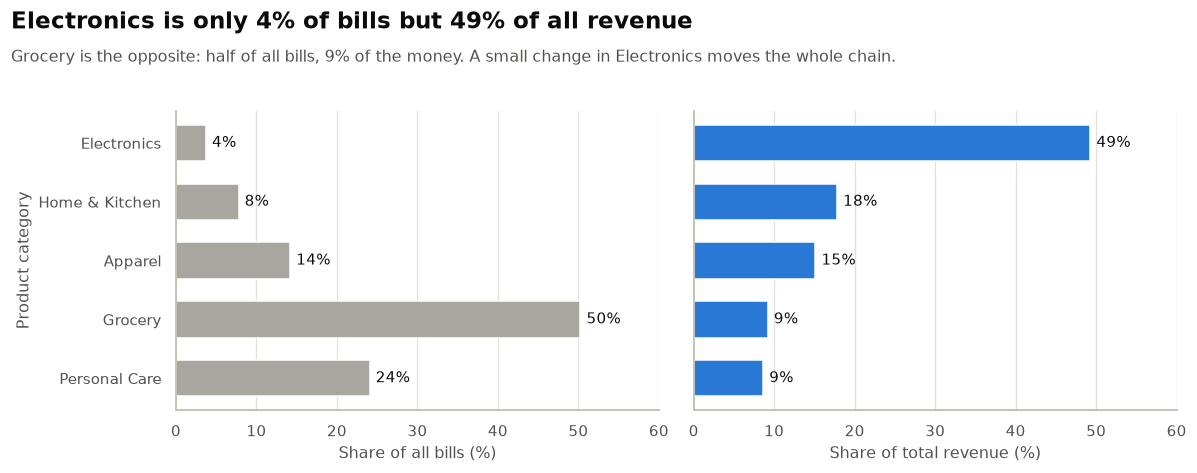

In [6]:
mix = df.groupby("category").agg(transactions=("transaction_id", "count"), revenue=("revenue", "sum"))
mix = (mix / mix.sum() * 100).sort_values("revenue")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
panels = [(axes[0], "transactions", "Share of all bills (%)", STABLE),
          (axes[1], "revenue", "Share of total revenue (%)", GROWING)]
for ax, column, label, colour in panels:
    bars = ax.barh(mix.index, mix[column], color=colour, height=0.62)
    ax.bar_label(bars, labels=[f"{v:.0f}%" for v in mix[column]], padding=4, color=INK, fontsize=10)
    ax.set_xlim(0, 60)
    ax.set_xlabel(label)
    ax.grid(False)
    ax.xaxis.grid(True)
axes[0].set_ylabel("Product category")
finish(fig, "Electronics is only 4% of bills but 49% of all revenue",
       "Grocery is the opposite: half of all bills, 9% of the money. A small change in Electronics moves the whole chain.")

### What we found (Step 6.1)
**The data is clean and trustworthy.** 107,836 transactions, 10 columns, **no missing values, no duplicates**, and revenue matches *units × price × (1 − discount)* to within half a paisa. There are **25 unique products** in **5 categories** (exactly 5 products each), sold across **12 stores in 6 cities** over **181 days** (1 Jan – 30 Jun 2026), totalling **₹45.98 Cr**.

**Observation 1 — a few big bills carry the business.** The *average* bill is ₹4,264 but the *median* bill is only ₹1,035, and the largest is ₹3.55 L. That gap means a small number of high-value Electronics bills make up most of the money. The chart confirms it: Electronics is 4% of bills but 49% of revenue. **For the Category Manager this means Electronics has the most power over the chain's results — a weak Electronics supplier hurts the whole business, not just one shelf.**

**Observation 2 — baskets are small, and discounts are frequent but capped at 20%.** Customers buy a median of 2 units per bill (max 13), and two out of three bills carry a discount (median 5%). The column guide says discounts run up to 30%, but **no bill in the data has more than 20%** — so the "25%+" bracket in Step 6.4 will be empty. With such small baskets, Step 6.4 tests whether deeper discounts come with *bigger* baskets. (This data cannot show whether discounts bring in extra customers.)

## Step 6.2 — Category revenue trend over time
**Owner:** Mohammed Saalif Udyawar (Data Analyst)

Monthly revenue for each category, January to June 2026. This is the chart the Category Manager should open the meeting with.

In [7]:
monthly = (df.pivot_table(index="month_num", columns="category", values="revenue", aggfunc="sum")
             .rename(index=dict(enumerate(MONTHS, start=1))))
monthly.index.name = "Month"

trend = pd.DataFrame({
    "Jan revenue": monthly.iloc[0],
    "Jun revenue": monthly.iloc[-1],
    "Change Jan→Jun (%)": (monthly.iloc[-1] / monthly.iloc[0] - 1) * 100,
    "Coefficient of variation (%)": monthly.std() / monthly.mean() * 100,
    "Share of revenue (%)": monthly.sum() / monthly.values.sum() * 100,
}).sort_values("Change Jan→Jun (%)")

print("Monthly revenue by category (₹ Lakh)")
display((monthly / 1e5).round(1))
print("Trend summary — coefficient of variation = standard deviation ÷ mean of monthly revenue (lower = more consistent)")
display(trend.assign(**{"Jan revenue": trend["Jan revenue"].map(to_lakh),
                        "Jun revenue": trend["Jun revenue"].map(to_lakh)}).round(1))

Monthly revenue by category (₹ Lakh)


category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
Month,,,,,
Jan,100.5,456.9,73.1,151.3,65.9
Feb,95.1,389.9,65.3,130.1,57.9
Mar,115.4,408.5,71.3,143.6,68.1
Apr,116.8,370.9,70.5,134.3,64.2
May,132.2,342.3,72.3,135.8,73.0
Jun,134.8,296.9,70.5,123.3,67.4


Trend summary — coefficient of variation = standard deviation ÷ mean of monthly revenue (lower = more consistent)


,Jan revenue,Jun revenue,Change Jan→Jun (%),Coefficient of variation (%),Share of revenue (%)
category,,,,,
Electronics,₹456.9 L,₹296.9 L,-35.0,14.6,49.3
Home & Kitchen,₹151.3 L,₹123.3 L,-18.5,7.3,17.8
Grocery,₹73.1 L,₹70.5 L,-3.5,3.9,9.2
Personal Care,₹65.9 L,₹67.4 L,2.2,7.5,8.6
Apparel,₹100.5 L,₹134.8 L,34.1,13.9,15.1


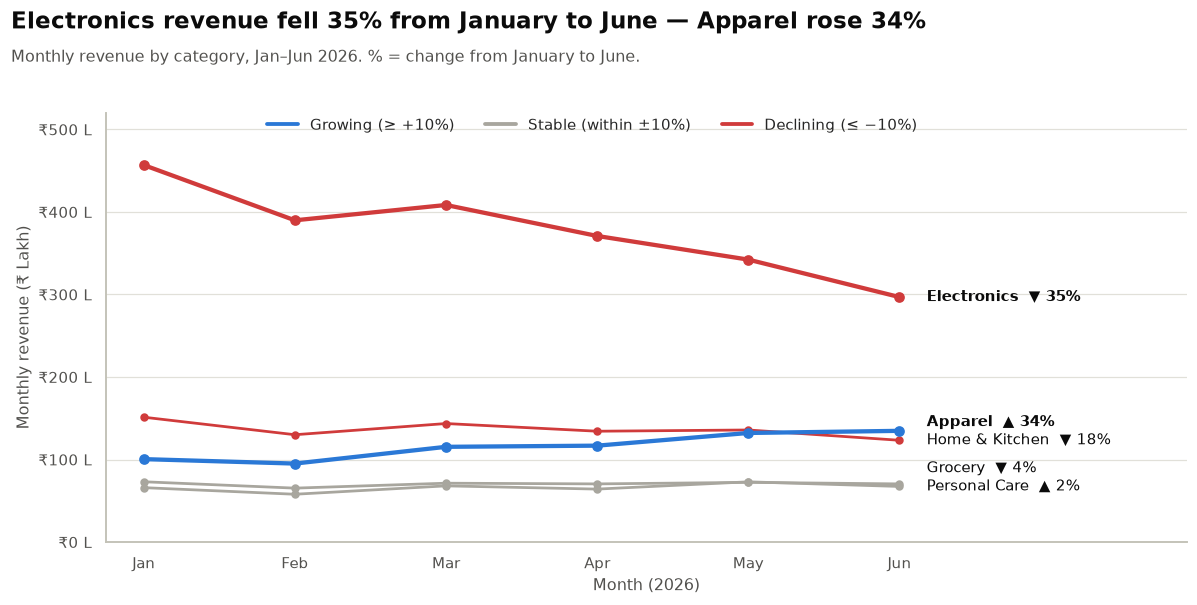

In [8]:
change = trend["Change Jan→Jun (%)"]
TREND_COLOUR = {cat: GROWING if c >= 10 else DECLINING if c <= -10 else STABLE for cat, c in change.items()}
KEY = ["Electronics", "Apparel"]


def plot_trend(data, ylabel, ylim, label_gap):
    fig, ax = plt.subplots(figsize=(11, 5.6))
    for cat in data.columns:
        key = cat in KEY
        ax.plot(MONTHS, data[cat], color=TREND_COLOUR[cat], linewidth=2.8 if key else 1.8,
                marker="o", markersize=6 if key else 4.5, zorder=3 if key else 2)
    ax.set_ylim(*ylim)
    label_y = spread_labels(data.iloc[-1].values, label_gap)
    for cat, y_end, y_label in zip(data.columns, data.iloc[-1].values, label_y):
        arrow = "▲" if change[cat] > 0 else "▼"
        ax.annotate(f"{cat}  {arrow} {abs(change[cat]):.0f}%", xy=(5, y_end), xytext=(5.18, y_label),
                    va="center", fontsize=10, color=INK, fontweight="bold" if cat in KEY else "normal")
    ax.set_xlim(-0.25, 6.9)
    ax.set_xticks(range(6), MONTHS)
    ax.set_xlabel("Month (2026)")
    ax.set_ylabel(ylabel)
    legend = [Line2D([], [], color=GROWING, lw=2.5, label="Growing (≥ +10%)"),
              Line2D([], [], color=STABLE, lw=2.5, label="Stable (within ±10%)"),
              Line2D([], [], color=DECLINING, lw=2.5, label="Declining (≤ −10%)")]
    ax.legend(handles=legend, loc="upper center", ncol=3, bbox_to_anchor=(0.45, 1.02))
    return fig, ax


fig, ax = plot_trend(monthly, "Monthly revenue (₹ Lakh)", (0, 520e5), 22e5)
ax.yaxis.set_major_formatter(lakh_axis)
finish(fig, "Electronics revenue fell 35% from January to June — Apparel rose 34%",
       "Monthly revenue by category, Jan–Jun 2026. % = change from January to June.")

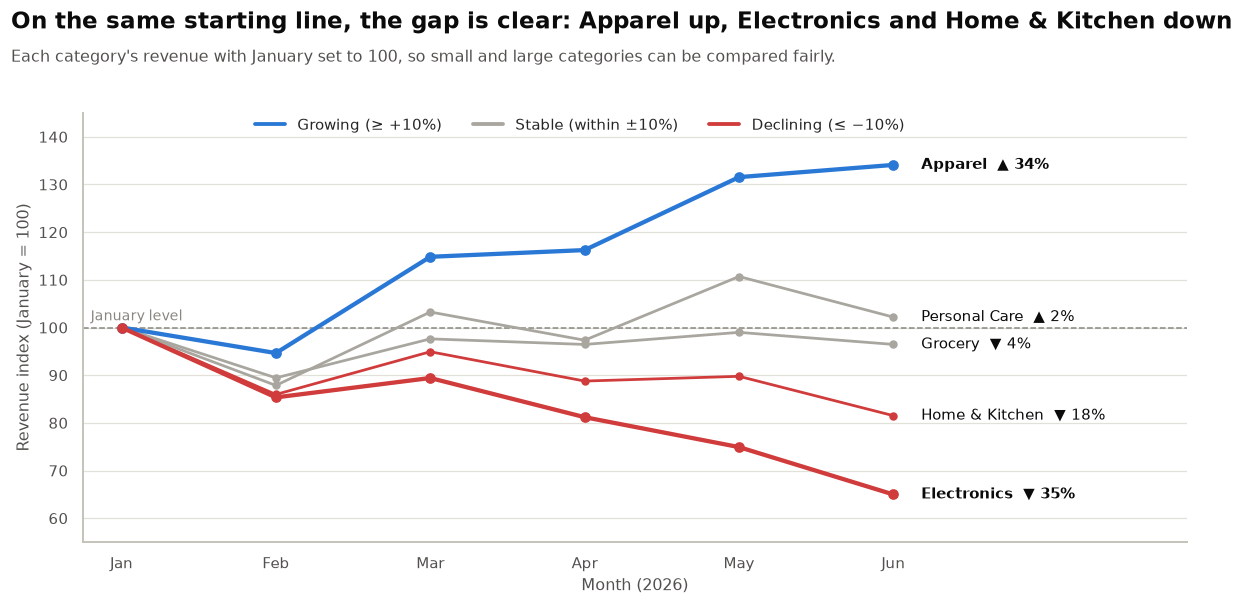

In [9]:
indexed = monthly / monthly.iloc[0] * 100

fig, ax = plot_trend(indexed, "Revenue index (January = 100)", (55, 145), 4.2)
ax.axhline(100, color=MUTED, linewidth=1, linestyle="--", zorder=1)
ax.text(-0.2, 101.5, "January level", fontsize=9, color=MUTED)
finish(fig, "On the same starting line, the gap is clear: Apparel up, Electronics and Home & Kitchen down",
       "Each category's revenue with January set to 100, so small and large categories can be compared fairly.")

In [10]:
# What moved: the number of transactions or the average unit price?
def jan_vs_jun(category):
    sub = df[df["category"] == category]
    jan, jun = sub[sub["month_num"] == 1], sub[sub["month_num"] == 6]
    return pd.Series({
        "Bills in Jan": len(jan), "Bills in Jun": len(jun),
        "Change in bills": f"{(len(jun) / len(jan) - 1) * 100:+.0f}%",
        "Avg unit price Jan": f"₹{jan['unit_price'].mean():,.0f}",
        "Avg unit price Jun": f"₹{jun['unit_price'].mean():,.0f}",
        "Change in price": f"{(jun['unit_price'].mean() / jan['unit_price'].mean() - 1) * 100:+.0f}%",
    }, name=category)


display(pd.concat([jan_vs_jun(c) for c in ["Electronics", "Home & Kitchen", "Apparel"]], axis=1).T)

chain = monthly.sum(axis=1)
without_electronics = chain - monthly["Electronics"]
print(f"Whole chain         : {to_crore(chain['Jan'])} in Jan → {to_crore(chain['Jun'])} in Jun ({(chain['Jun'] / chain['Jan'] - 1) * 100:+.1f}%)")
print(f"Electronics alone   : {to_crore(monthly['Electronics']['Jan'])} → {to_crore(monthly['Electronics']['Jun'])} "
      f"(June was {to_crore(monthly['Electronics']['Jan'] - monthly['Electronics']['Jun'])} below January)")
print(f"Chain w/o Electronics: {to_crore(without_electronics['Jan'])} → {to_crore(without_electronics['Jun'])} "
      f"({(without_electronics['Jun'] / without_electronics['Jan'] - 1) * 100:+.1f}%)")

,Bills in Jan,Bills in Jun,Change in bills,Avg unit price Jan,Avg unit price Jun,Change in price
Electronics,790,526,-33%,"₹24,183","₹23,659",-2%
Home & Kitchen,1575,1266,-20%,"₹4,020","₹4,130",+3%
Apparel,2233,2931,+31%,"₹1,916","₹1,914",-0%


Whole chain         : ₹8.48 Cr in Jan → ₹6.93 Cr in Jun (-18.3%)
Electronics alone   : ₹4.57 Cr → ₹2.97 Cr (June was ₹1.60 Cr below January)
Chain w/o Electronics: ₹3.91 Cr → ₹3.96 Cr (+1.3%)


### What this means for the supplier review (Step 6.2)
**Steepest decline — Electronics (−35%).** Monthly revenue fell from **₹4.57 Cr in January to ₹2.97 Cr in June** — **June revenue was ₹1.60 Cr below January**. Because Electronics is half the chain's revenue, its fall is larger than the chain's entire decline: the chain fell from ₹8.48 Cr to ₹6.93 Cr (−18%), while the other four categories together rose slightly (+1.3%). Average unit price barely moved (−2%); instead, **Electronics transactions fell 33%**. The data does not establish whether the cause is stock availability, competition, pricing, or customer demand. **Signal:** before renewing shelf space or promotional money, the Electronics supplier should explain the decline, and the Category Manager should investigate range, availability and price competitiveness.

**Most consistent performer — Grocery.** Grocery has the **lowest coefficient of variation in monthly revenue, at 3.9%** (always between ₹65 L and ₹73 L). It accounts for half of all recorded transactions; its contribution to customer visits cannot be established from this data. **Signal:** a stable category — no case for cuts or for extra investment.

**Best growth story — Apparel (+34%).** Apparel rose from ₹1.01 Cr to ₹1.35 Cr, and **recorded Apparel transactions increased 31%**; customer and seasonal data are needed to explain the increase. It is the only category to grow strongly. **Signal:** Apparel has the strongest case for more shelf space. **Home & Kitchen (−18%)** is the second concern — its transactions fell 20% — and should be put on watch.

## Step 6.3 — Top and bottom products by category
**Owner:** Mohammed Saalif Udyawar (Data Analyst)

Top 2 and bottom 2 products in each category by total six-month revenue, plus each product's January→June direction (total revenue alone can hide a product that is collapsing).

In [11]:
jan_rev = df[df["month_num"] == 1].groupby("product_name")["revenue"].sum()
jun_rev = df[df["month_num"] == 6].groupby("product_name")["revenue"].sum()

products = df.groupby(["category", "product_name"], as_index=False)["revenue"].sum()
products["rank"] = products.groupby("category")["revenue"].rank(ascending=False).astype(int)
products["share"] = products["revenue"] / products.groupby("category")["revenue"].transform("sum") * 100
products["change"] = products["product_name"].map((jun_rev / jan_rev - 1) * 100)

top_bottom = pd.concat([products[products["rank"] <= 2].assign(Position="Top 2"),
                        products[products["rank"] >= 4].assign(Position="Bottom 2")])
top_bottom = top_bottom.sort_values(["category", "rank"])
summary_table = pd.DataFrame({
    "Category": top_bottom["category"],
    "Position": top_bottom["Position"],
    "Rank (of 5)": top_bottom["rank"],
    "Product": top_bottom["product_name"],
    "6-month revenue": top_bottom["revenue"].map(to_lakh),
    "Share of category": top_bottom["share"].map(lambda v: f"{v:.1f}%"),
    "Jan→Jun change": top_bottom["change"].map(lambda v: f"{v:+.0f}%"),
}).set_index(["Category", "Position"])
display(summary_table)

spread = products.groupby("category")["revenue"].agg(lambda s: (s.max() - s.min()) / s.max() * 100)
print("Gap between the best and worst product in each category (% of the best):")
print(spread.round(1).sort_values(ascending=False).to_string())

Rank (of 5)          Product 6-month revenue  \
Category       Position                                                 
Apparel        Top 2               1            Saree        ₹141.6 L   
               Top 2               2          T-Shirt        ₹141.0 L   
               Bottom 2            4     Formal Shirt        ₹137.5 L   
               Bottom 2            5            Kurta        ₹136.1 L   
Electronics    Top 2               1       Headphones        ₹477.0 L   
               Top 2               2           Laptop        ₹465.5 L   
               Bottom 2            4           Tablet        ₹447.4 L   
               Bottom 2            5         Smart TV        ₹418.8 L   
Grocery        Top 2               1       Rice (5kg)         ₹85.6 L   
               Top 2               2        Dal (1kg)         ₹84.9 L   
               Bottom 2            4         Oil (1L)         ₹84.3 L   
               Bottom 2            5      Sugar (1kg)         ₹83.8 L   
Home & Kitchen Top 2               1    Mixer Grinder        ₹169.0 L   
               Top 2               2      Storage Box        ₹166.8 L   
               Bottom 2            4  Pressure Cooker        ₹161.4 L   
               Bottom 2            5     Water Bottle        ₹158.3 L   
Personal Care  Top 2               1          Shampoo         ₹81.7 L   
               Top 2               2      Body Lotion         ₹81.1 L   
               Bottom 2            4       Toothpaste         ₹77.7 L   
               Bottom 2            5        Sunscreen         ₹75.9 L   

                        Share of category Jan→Jun change  
Category       Position                                   
Apparel        Top 2                20.4%           +33%  
               Top 2                20.3%           +45%  
               Bottom 2             19.8%           +35%  
               Bottom 2             19.6%           +18%  
Electronics    Top 2                21.1%           -20%  
               Top 2                20.5%           -31%  
               Bottom 2             19.8%           -41%  
               Bottom 2             18.5%           -22%  
Grocery        Top 2                20.2%            -1%  
               Top 2                20.1%            -7%  
               Bottom 2             19.9%            -5%  
               Bottom 2             19.8%            +1%  
Home & Kitchen Top 2                20.7%           -22%  
               Top 2                20.4%           -11%  
               Bottom 2             19.7%           -12%  
               Bottom 2             19.3%           -20%  
Personal Care  Top 2                20.6%            -1%  
               Top 2                20.4%            +5%  
               Bottom 2             19.6%            +3%  
               Bottom 2             19.2%            +6%

Gap between the best and worst product in each category (% of the best):
category
Electronics       12.2
Personal Care      7.0
Home & Kitchen     6.4
Apparel            3.9
Grocery            2.2


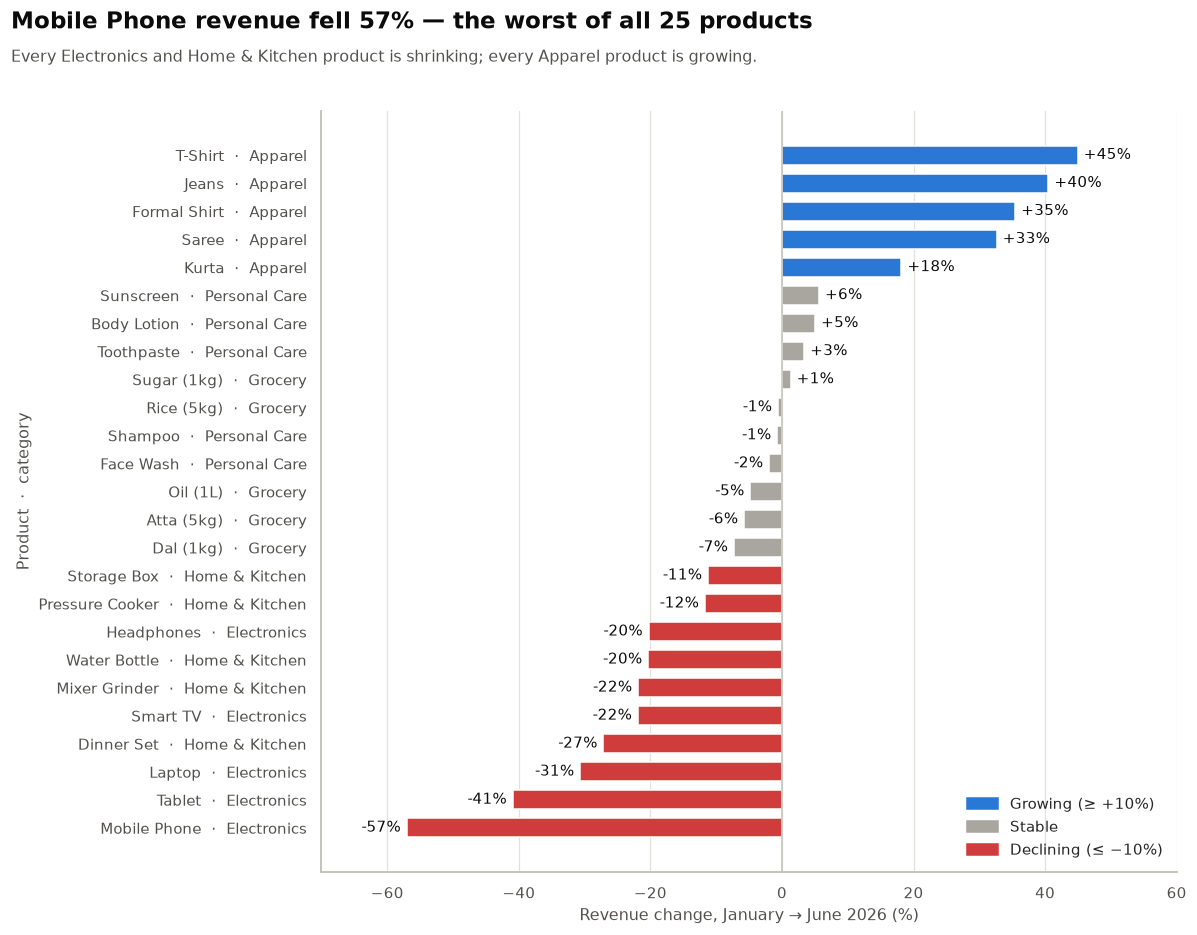

In [12]:
momentum = products.sort_values("change")
colours = [GROWING if c >= 10 else DECLINING if c <= -10 else STABLE for c in momentum["change"]]
labels = [f"{p}  ·  {c}" for p, c in zip(momentum["product_name"], momentum["category"])]

fig, ax = plt.subplots(figsize=(11, 8.6))
bars = ax.barh(labels, momentum["change"], color=colours, height=0.68)
ax.bar_label(bars, labels=[f"{v:+.0f}%" for v in momentum["change"]], padding=4, fontsize=9.5, color=INK)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlim(-70, 60)
ax.set_xlabel("Revenue change, January → June 2026 (%)")
ax.set_ylabel("Product  ·  category")
ax.grid(False)
ax.xaxis.grid(True)
ax.legend(handles=[Patch(color=GROWING, label="Growing (≥ +10%)"), Patch(color=STABLE, label="Stable"),
                   Patch(color=DECLINING, label="Declining (≤ −10%)")], loc="lower right")
finish(fig, "Mobile Phone revenue fell 57% — the worst of all 25 products",
       "Every Electronics and Home & Kitchen product is shrinking; every Apparel product is growing.")

In [13]:
# Is the Electronics fall a problem in one store, or everywhere?
elec_city = df[df["category"] == "Electronics"].pivot_table(index="store_city", columns="month_num", values="revenue", aggfunc="sum")
mobile = df[df["product_name"] == "Mobile Phone"].groupby("month_num").agg(revenue=("revenue", "sum"), bills=("transaction_id", "count"))
mobile.index = MONTHS

print("Electronics revenue change Jan→Jun, by city:")
print(((elec_city[6] / elec_city[1] - 1) * 100).sort_values().map(lambda v: f"{v:+.0f}%").to_string())
print("\nMobile Phone, month by month:")
display(mobile.assign(revenue=mobile["revenue"].map(to_lakh)))

Electronics revenue change Jan→Jun, by city:
store_city
Guntur         -45%
Tirupati       -44%
Vijayawada     -37%
Rajahmundry    -27%
Nellore        -25%
Kakinada       -15%

Mobile Phone, month by month:


,revenue,bills
Jan,₹98.0 L,177
Feb,₹78.6 L,138
Mar,₹86.9 L,143
Apr,₹77.2 L,128
May,₹73.6 L,123
Jun,₹42.1 L,87


### Which supplier to challenge (Step 6.3)
**A total-revenue ranking alone would point to the wrong product.** Inside each category the five products earn almost the same over six months (Grocery's best and worst are just 2% apart; Electronics' 12%). So "bottom 2" is not where the problem is — **the direction of travel is**.

**Challenge the Electronics supplier, and open with Mobile Phones.** Mobile Phone is only *3rd* of 5 by total revenue (₹456.5 L), so it looks safe on a table — but it fell from **₹98.0 L in January to ₹42.1 L in June (−57%)**, and its transactions roughly halved (177 → 87). Tablet (−41%) and Laptop (−31%) are close behind; **all five Electronics products declined**, and the fall happened **in every one of the six cities** (−15% to −45%). So the decline is not confined to one store. The data does not show the cause — range, availability, pricing or demand — and that is what the supplier should be asked to explain. Electronics' bottom 2 by total — **Smart TV (₹418.8 L)** and **Tablet (₹447.4 L)** — should be the first candidates to lose shelf space if the supplier has no recovery plan.

By contrast, **all five Apparel products grew** (T-Shirt +45%, Jeans +40%), so there is no Apparel product to challenge — the conversation there is about more stock.

## Step 6.4 — Discount effectiveness analysis
**Owner:** Mohammed Mutee Ruknuddin (Business Synthesiser)

If deeper discounts grew basket size, higher-discount transactions would show more **units per transaction**. We place every transaction in its exact discount bracket and compare revenue and units. *This tests basket size only — not whether discounts attract additional customers.*

In [14]:
BRACKETS = ["0%", "5%", "10%", "15%", "20%", "25%+"]
# Each bracket is one exact discount level; "25%+" only takes discounts of 25% or more,
# so a value such as 22% can never fall into it silently.
df["discount_bracket"] = df["discount_pct"].map({0: "0%", 5: "5%", 10: "10%", 15: "15%", 20: "20%"})
df.loc[df["discount_pct"] >= 25, "discount_bracket"] = "25%+"
unassigned = df["discount_bracket"].isna().sum()
print("Transactions with a discount outside the defined brackets:", unassigned)
assert unassigned == 0, "Unexpected discount levels found — review the bracket definitions before continuing."
df["discount_bracket"] = pd.Categorical(df["discount_bracket"], categories=BRACKETS, ordered=True)
df["discount_given"] = df["units_sold"] * df["unit_price"] - df["revenue"]

discounts = df.groupby("discount_bracket", observed=False).agg(
    bills=("transaction_id", "count"),
    avg_revenue=("revenue", "mean"),
    avg_units=("units_sold", "mean"),
    avg_unit_price=("unit_price", "mean"),
    discount_given=("discount_given", "sum"),
)
discounts["vs_no_discount"] = (discounts["avg_revenue"] / discounts.loc["0%", "avg_revenue"] - 1) * 100

display(pd.DataFrame({
    "Bills": discounts["bills"].map("{:,}".format),
    "Share of bills": (discounts["bills"] / discounts["bills"].sum() * 100).map(lambda v: f"{v:.0f}%"),
    "Avg revenue per bill": discounts["avg_revenue"].map(lambda v: f"₹{v:,.0f}" if pd.notna(v) else "no bills"),
    "vs. no discount": discounts["vs_no_discount"].map(lambda v: f"{v:+.0f}%" if pd.notna(v) else "—"),
    "Avg units per bill": discounts["avg_units"].round(2).fillna("—"),
    "Avg unit price (before discount)": discounts["avg_unit_price"].map(lambda v: f"₹{v:,.0f}" if pd.notna(v) else "—"),
    "Discount given": discounts["discount_given"].map(to_lakh),
}))
total_given = df["discount_given"].sum()
print(f"Total discount given in six months: {to_crore(total_given)} "
      f"({total_given / (df['revenue'].sum() + total_given) * 100:.1f}% of pre-discount sales)")

Transactions with a discount outside the defined brackets: 0


,Bills,Share of bills,Avg revenue per bill,vs. no discount,Avg units per bill,Avg unit price (before discount),Discount given
discount_bracket,,,,,,,
0%,"36,033",33%,"₹4,686",+0%,2.59,"₹1,815",₹0.0 L
5%,"23,922",22%,"₹4,304",-8%,2.59,"₹1,750",₹54.2 L
10%,"23,810",22%,"₹4,006",-15%,2.57,"₹1,747",₹106.0 L
15%,"11,935",11%,"₹4,069",-13%,2.6,"₹1,808",₹85.7 L
20%,"12,136",11%,"₹3,632",-22%,2.58,"₹1,758",₹110.2 L
25%+,0,0%,no bills,—,—,—,₹0.0 L


Total discount given in six months: ₹3.56 Cr (7.2% of pre-discount sales)


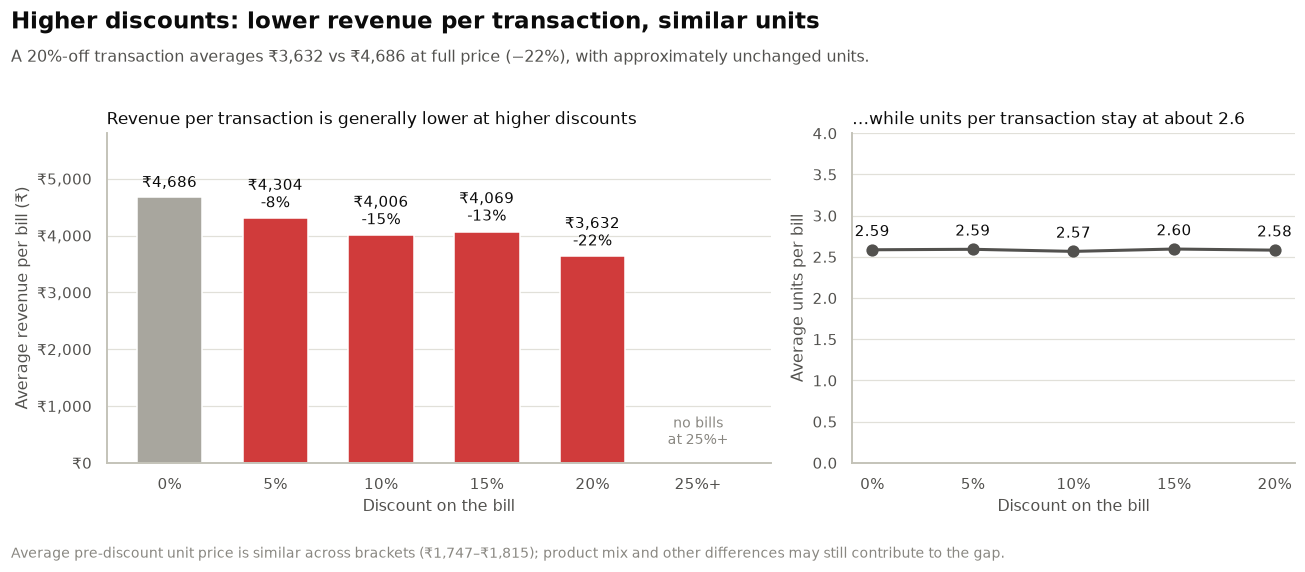

In [15]:
shown = discounts.dropna(subset=["avg_revenue"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
bar_colours = [STABLE] + [DECLINING] * (len(shown) - 1)
bars = ax.bar(shown.index.astype(str), shown["avg_revenue"], color=bar_colours, width=0.62)
ax.bar_label(bars, labels=[f"₹{r:,.0f}" + ("" if b == "0%" else f"\n{d:+.0f}%")
                           for b, r, d in zip(shown.index, shown["avg_revenue"], shown["vs_no_discount"])],
             padding=4, fontsize=9.5, color=INK)
ax.bar(["25%+"], [0])
ax.text(5, 250, "no bills\nat 25%+", ha="center", va="bottom", fontsize=9, color=MUTED)
ax.set_ylim(0, 5800)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"₹{v:,.0f}"))
ax.set_xlabel("Discount on the bill")
ax.set_ylabel("Average revenue per bill (₹)")
ax.set_title("Revenue per transaction is generally lower at higher discounts", loc="left", fontsize=11, color=INK)

ax = axes[1]
ax.plot(shown.index.astype(str), shown["avg_units"], color=INK_SOFT, marker="o", markersize=7, linewidth=2)
for x, units in enumerate(shown["avg_units"]):
    ax.annotate(f"{units:.2f}", (x, units), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9.5, color=INK)
ax.set_ylim(0, 4)
ax.set_xlabel("Discount on the bill")
ax.set_ylabel("Average units per bill")
ax.set_title("…while units per transaction stay at about 2.6", loc="left", fontsize=11, color=INK)

finish(fig, "Higher discounts: lower revenue per transaction, similar units",
       "A 20%-off transaction averages ₹3,632 vs ₹4,686 at full price (−22%), with approximately unchanged units.",
       note="Average pre-discount unit price is similar across brackets (₹1,747–₹1,815); product mix and other differences may still contribute to the gap.")

In [16]:
# Same comparison within each category (reduces, but does not remove, product-mix effects)
by_cat = df[df["discount_pct"].isin([0, 20])].pivot_table(index="category", columns="discount_pct",
                                                          values=["units_sold", "revenue"], aggfunc="mean")
display(pd.DataFrame({
    "Units/bill at 0%": by_cat["units_sold"][0].round(2),
    "Units/bill at 20%": by_cat["units_sold"][20].round(2),
    "Revenue/bill at 0%": by_cat["revenue"][0].map(lambda v: f"₹{v:,.0f}"),
    "Revenue/bill at 20%": by_cat["revenue"][20].map(lambda v: f"₹{v:,.0f}"),
    "Revenue change": ((by_cat["revenue"][20] / by_cat["revenue"][0] - 1) * 100).map(lambda v: f"{v:+.0f}%"),
    "Discount given (6 months)": df.groupby("category")["discount_given"].sum().map(to_lakh),
}))

share_with_discount = df.assign(discounted=df["discount_pct"] > 0).groupby("month_num")["discounted"].mean() * 100
print("Share of bills with a discount, by month:", ", ".join(f"{m} {v:.0f}%" for m, v in zip(MONTHS, share_with_discount)))

,Units/bill at 0%,Units/bill at 20%,Revenue/bill at 0%,Revenue/bill at 20%,Revenue change,Discount given (6 months)
category,,,,,,
Apparel,2.59,2.58,"₹4,918","₹3,872",-21%,₹53.7 L
Electronics,2.57,2.63,"₹61,151","₹48,085",-21%,₹175.7 L
Grocery,2.59,2.58,₹844,₹669,-21%,₹33.1 L
Home & Kitchen,2.58,2.62,"₹10,635","₹8,608",-19%,₹62.9 L
Personal Care,2.58,2.57,"₹1,645","₹1,302",-21%,₹30.7 L


Share of bills with a discount, by month: Jan 67%, Feb 67%, Mar 67%, Apr 67%, May 66%, Jun 67%


### Position: deeper discounts are not paying back in basket size (Step 6.4)
**Higher discounts are associated with lower revenue per transaction without a meaningful increase in units per transaction. This supports challenging deeper discounts, but does not establish their effect on total demand or profit.**

- A full-price transaction averages **₹4,686**; a 20%-off transaction averages **₹3,632 (−22%)**, with **2.59 vs 2.58 units**.
- Revenue per transaction is *generally* lower at higher discounts — the 15% bracket (₹4,069) is slightly above the 10% bracket (₹4,006) — while units stay at about 2.6 at every level.
- Within every category the pattern repeats: at 20% off, revenue per transaction is 19–21% lower than at full price, with no meaningful unit increase.
- Average pre-discount unit price is similar across brackets (₹1,747–₹1,815), but product mix and other differences may still contribute, so the gap should not be read as caused by the discount alone.
- The chain recorded **₹3.56 Cr of discounts in six months** (7.2% of pre-discount sales), **₹1.76 Cr of it on Electronics**. About two-thirds of transactions carried a discount in every month.

**Proposed policy to test:** cap store-funded discounts at 10%, with deeper discounts supplier-funded and tied to a measurable volume target. The 10% level is a management choice to trial and review — this analysis does not show it is the optimal threshold. *Limitation:* the data shows neither whether discounts brought in additional customers nor what each sale cost.

## Step 6.5 — Day-of-week and monthly patterns
**Owner:** Jakkana Hasini (Insights Lead)

When does the chain naturally sell well, and when is it quiet? This helps decide when promotions are worth testing.

In [17]:
daily = df.groupby("date")["revenue"].sum().to_frame()
daily["day_name"] = daily.index.day_name()
by_day = daily.groupby("day_name")["revenue"].mean().reindex(DAYS)
by_month = df.groupby("month_num")["revenue"].sum().rename(index=dict(enumerate(MONTHS, start=1)))
days_in_month = daily.groupby(daily.index.month).size().rename(index=dict(enumerate(MONTHS, start=1)))

print(f"Chain best day   : {by_day.idxmax()} ({to_lakh(by_day.max())} per day)")
print(f"Chain worst day  : {by_day.idxmin()} ({to_lakh(by_day.min())} per day)  → Saturday is {(by_day.max() / by_day.min() - 1) * 100:.0f}% higher")
print(f"Chain best month : {by_month.idxmax()} ({to_crore(by_month.max())})")
print(f"Chain worst month: {by_month.idxmin()} ({to_crore(by_month.min())})")

Chain best day   : Saturday (₹35.2 L per day)
Chain worst day  : Monday (₹20.1 L per day)  → Saturday is 75% higher
Chain best month : Jan (₹8.48 Cr)
Chain worst month: Jun (₹6.93 Cr)


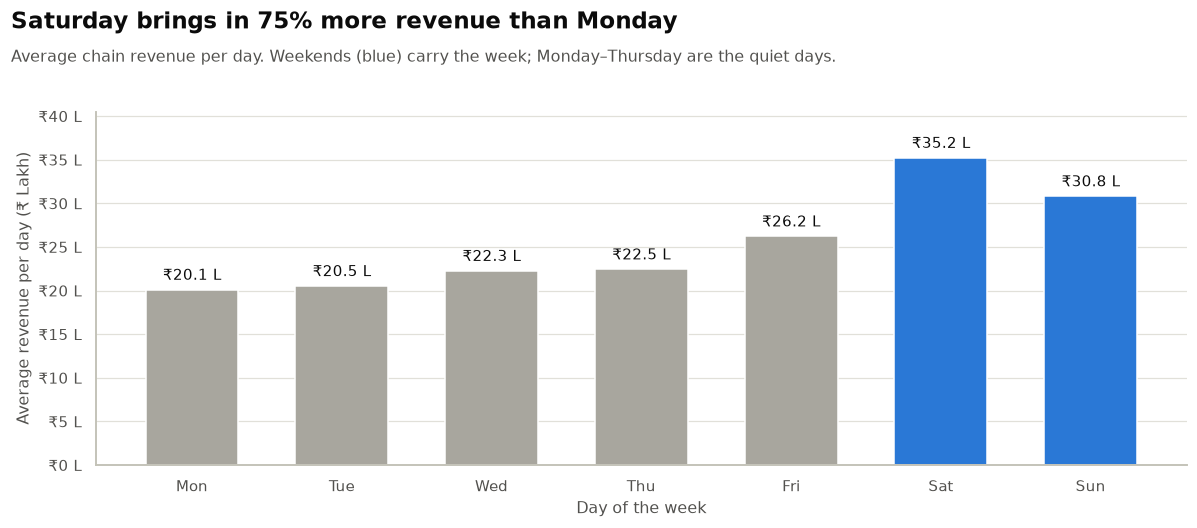

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.9))
day_colours = [GROWING if d in ("Saturday", "Sunday") else STABLE for d in DAYS]
bars = ax.bar([d[:3] for d in DAYS], by_day.values, color=day_colours, width=0.62)
ax.bar_label(bars, labels=[to_lakh(v) for v in by_day.values], padding=4, fontsize=10, color=INK)
ax.yaxis.set_major_formatter(lakh_axis)
ax.set_ylim(0, by_day.max() * 1.15)
ax.set_xlabel("Day of the week")
ax.set_ylabel("Average revenue per day (₹ Lakh)")
finish(fig, "Saturday brings in 75% more revenue than Monday",
       "Average chain revenue per day. Weekends (blue) carry the week; Monday–Thursday are the quiet days.")

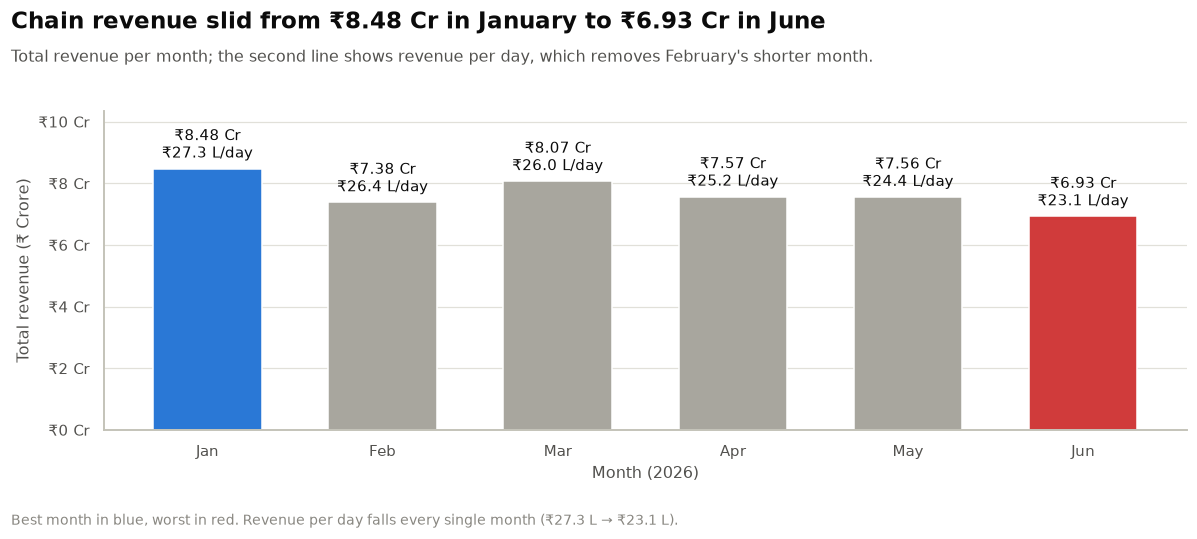

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.9))
month_colours = [GROWING if m == by_month.idxmax() else DECLINING if m == by_month.idxmin() else STABLE for m in MONTHS]
bars = ax.bar(MONTHS, by_month.values, color=month_colours, width=0.62)
ax.bar_label(bars, labels=[f"{to_crore(v)}\n{to_lakh(v / days_in_month[m])}/day" for m, v in by_month.items()],
             padding=4, fontsize=9.5, color=INK)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"₹{v / 1e7:,.0f} Cr"))
ax.set_ylim(0, by_month.max() * 1.22)
ax.set_xlabel("Month (2026)")
ax.set_ylabel("Total revenue (₹ Crore)")
finish(fig, "Chain revenue slid from ₹8.48 Cr in January to ₹6.93 Cr in June",
       "Total revenue per month; the second line shows revenue per day, which removes February's shorter month.",
       note="Best month in blue, worst in red. Revenue per day falls every single month (₹27.3 L → ₹23.1 L).")

**Which category to look at more closely?** From Step 6.2, **Apparel** is the most interesting: it is the only category growing strongly (+34%) *while the chain shrinks*. Electronics is not a separate story here — at 49% of revenue, the chain's pattern largely *is* the Electronics pattern.

In [20]:
FOCUS = "Apparel"
focus = df[df["category"] == FOCUS]
focus_daily = focus.groupby("date")["revenue"].sum().to_frame()
focus_daily["day_name"] = focus_daily.index.day_name()
focus_by_day = focus_daily.groupby("day_name")["revenue"].mean().reindex(DAYS)
focus_by_month = focus.groupby("month_num")["revenue"].sum().rename(index=dict(enumerate(MONTHS, start=1)))

comparison = pd.DataFrame({
    "Chain": [by_day.idxmax(), by_day.idxmin(), by_month.idxmax(), by_month.idxmin()],
    FOCUS: [focus_by_day.idxmax(), focus_by_day.idxmin(), focus_by_month.idxmax(), focus_by_month.idxmin()],
}, index=["Best day", "Worst day", "Best month", "Worst month"])
display(comparison)
print(f"{FOCUS}: {focus_by_day.idxmax()} is {(focus_by_day.max() / focus_by_day.min() - 1) * 100:.0f}% above {focus_by_day.idxmin()}; "
      f"{focus_by_month.idxmax()} ({to_lakh(focus_by_month.max())}) vs {focus_by_month.idxmin()} ({to_lakh(focus_by_month.min())})")

,Chain,Apparel
Best day,Saturday,Saturday
Worst day,Monday,Monday
Best month,Jan,Jun
Worst month,Jun,Feb


Apparel: Saturday is 60% above Monday; Jun (₹134.8 L) vs Feb (₹95.1 L)


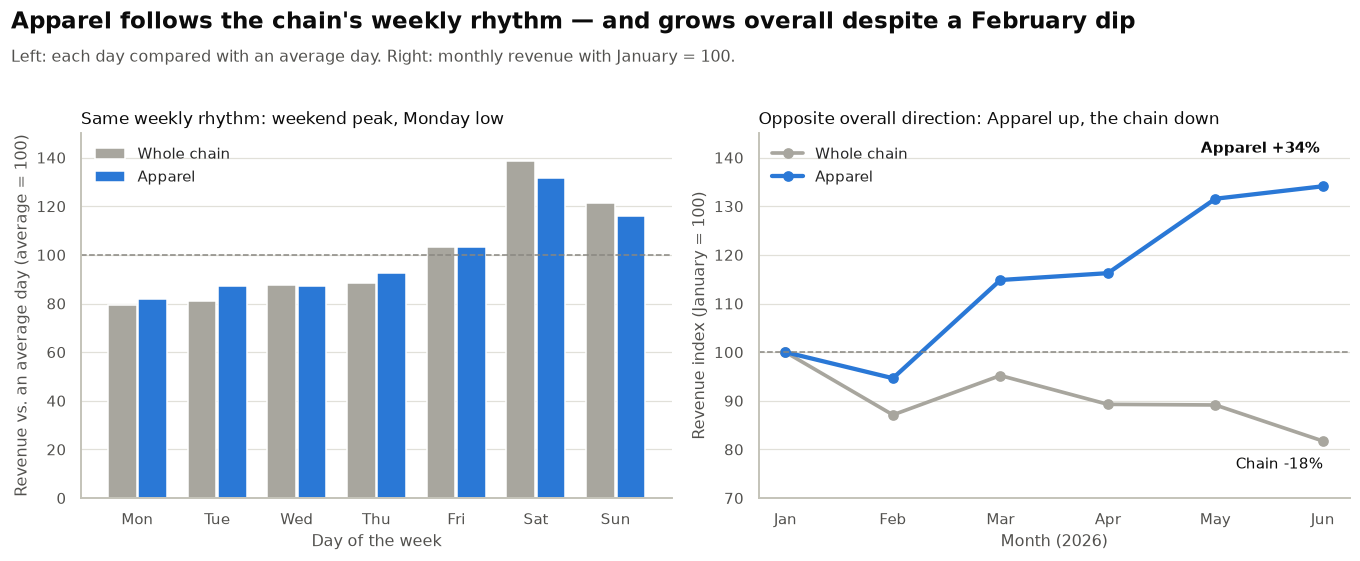

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

ax = axes[0]
x = np.arange(len(DAYS))
chain_profile = by_day / by_day.mean() * 100
focus_profile = focus_by_day / focus_by_day.mean() * 100
ax.bar(x - 0.19, chain_profile, width=0.36, color=STABLE, label="Whole chain")
ax.bar(x + 0.19, focus_profile, width=0.36, color=GROWING, label=FOCUS)
ax.axhline(100, color=MUTED, linewidth=1, linestyle="--")
ax.set_xticks(x, [d[:3] for d in DAYS])
ax.set_ylim(0, 150)
ax.set_xlabel("Day of the week")
ax.set_ylabel("Revenue vs. an average day (average = 100)")
ax.set_title("Same weekly rhythm: weekend peak, Monday low", loc="left", fontsize=11, color=INK)
ax.legend(loc="upper left")

ax = axes[1]
chain_index = by_month / by_month.iloc[0] * 100
focus_index = focus_by_month / focus_by_month.iloc[0] * 100
ax.plot(MONTHS, chain_index, color=STABLE, linewidth=2.4, marker="o", label="Whole chain")
ax.plot(MONTHS, focus_index, color=GROWING, linewidth=2.8, marker="o", label=FOCUS)
ax.axhline(100, color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"{FOCUS} {focus_index.iloc[-1] - 100:+.0f}%", (5, focus_index.iloc[-1]), xytext=(-2, 22),
            textcoords="offset points", ha="right", fontsize=10, fontweight="bold", color=INK)
ax.annotate(f"Chain {chain_index.iloc[-1] - 100:+.0f}%", (5, chain_index.iloc[-1]), xytext=(0, -18),
            textcoords="offset points", ha="right", fontsize=10, color=INK)
ax.set_ylim(70, 145)
ax.set_xlabel("Month (2026)")
ax.set_ylabel("Revenue index (January = 100)")
ax.set_title("Opposite overall direction: Apparel up, the chain down", loc="left", fontsize=11, color=INK)
ax.legend(loc="upper left")

finish(fig, "Apparel follows the chain's weekly rhythm — and grows overall despite a February dip",
       "Left: each day compared with an average day. Right: monthly revenue with January = 100.")

### What this means for promotional timing (Step 6.5)
**Chain:** best day **Saturday** (₹35.2 L/day), worst day **Monday** (₹20.1 L/day — Saturday is 75% higher); best month **January** (₹8.48 Cr), worst month **June** (₹6.93 Cr), with revenue per day lower in each successive month. **Apparel** follows the **same weekly rhythm** (best Saturday, worst Monday) but moves in the **opposite overall direction** to the chain: it grows overall despite a February dip — best month **June (₹134.8 L)**, worst **February (₹95.1 L)**.

**Promotional timing:** strong weekend sales suggest testing weekday (Monday–Thursday) promotions; the incremental impact of promotions remains unmeasured in this data, so any test should compare transactions with similar stores or weeks that had no promotion. For Apparel, the request to the supplier is stock depth and weekday visibility rather than deeper discounts. For Electronics, the decline continued in every month, so timing alone is unlikely to be the answer — investigate range, availability and price competitiveness before deciding the corrective action.

## Step 6.6 — Recommendation to the Category Manager
**Owner:** Mohammed Mutee Ruknuddin (Business Synthesiser), drawing on findings from every section

One table that pulls every step together, followed by the briefing.

In [22]:
consistency = trend["Coefficient of variation (%)"].map(lambda v: "Very steady" if v < 5 else "Steady" if v < 10 else "Volatile")
VERDICT = {  # judgement based on Steps 6.2 – 6.5
    "Apparel": "INVEST — more shelf space & stock",
    "Electronics": "CHALLENGE — supplier to explain −35%",
    "Home & Kitchen": "WATCH — sliding, review next quarter",
    "Grocery": "HOLD — steady; half of all transactions",
    "Personal Care": "HOLD — steady, low risk",
}
scorecard = pd.DataFrame({
    "6-month revenue": monthly.sum().map(to_crore),
    "Share of revenue": trend["Share of revenue (%)"].map(lambda v: f"{v:.0f}%"),
    "Jan→Jun trend": trend["Change Jan→Jun (%)"].map(lambda v: f"{v:+.0f}%"),
    "Month-to-month": consistency,
    "Discount given": df.groupby("category")["discount_given"].sum().map(to_lakh),
    "Verdict": pd.Series(VERDICT),
}).loc[["Apparel", "Electronics", "Home & Kitchen", "Grocery", "Personal Care"]]
scorecard.index.name = "Category"


def verdict_colour(value):
    colour = {"INVEST": GROWING, "CHALLENGE": DECLINING, "WATCH": "#b3541e"}.get(value.split(" ")[0], INK_SOFT)
    return f"color: {colour}; font-weight: bold"


scorecard.style.map(verdict_colour, subset=["Verdict"])

,6-month revenue,Share of revenue,Jan→Jun trend,Month-to-month,Discount given,Verdict
Category,,,,,,
Apparel,₹6.95 Cr,15%,+34%,Volatile,₹53.7 L,INVEST — more shelf space & stock
Electronics,₹22.65 Cr,49%,-35%,Volatile,₹175.7 L,CHALLENGE — supplier to explain −35%
Home & Kitchen,₹8.18 Cr,18%,-18%,Steady,₹62.9 L,"WATCH — sliding, review next quarter"
Grocery,₹4.23 Cr,9%,-4%,Very steady,₹33.1 L,HOLD — steady; half of all transactions
Personal Care,₹3.96 Cr,9%,+2%,Steady,₹30.7 L,"HOLD — steady, low risk"


## Category Manager Briefing
*Prepared by Mohammed Mutee Ruknuddin (Group 10), using findings from Steps 6.2–6.5.*

Back Apparel with additional shelf space and stock: its revenue grew **34%** from January to June (₹1.01 Cr → ₹1.35 Cr), with all five products up *(Step 6.2)*. Challenge the Electronics supplier, starting with Mobile Phones, whose monthly revenue fell from **₹98.0 lakh to ₹42.1 lakh**, and ask for an explanation — range, availability or pricing — before shelf space and promotional funding are renewed *(Steps 6.2–6.3)*. On discounts, a 20%-off transaction averages **₹3,632 against ₹4,686** at full price with approximately unchanged units (2.58 vs 2.59), so we should push for deeper discounts to be supplier-funded and trial a 10% cap on store-funded discounts *(Step 6.4)*. Before any final shelf-space or delisting decision, we need **product-level cost and margin data**, because revenue alone cannot show which category earns the most profit.